<a href="https://colab.research.google.com/github/kunal023-eng/network-anomaly-detection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Network Intrusion Anomaly Detection
**Goal:** Use an unsupervised machine learning model (Isolation Forest) to detect abnormal network traffic and potential cyber threats without using labeled data.


## 1. Environment Setup

In [12]:
# Data Manipulation
import pandas as pd
import numpy as np

#Visualization (for our EDA and Evaluation phases)
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.ensemble import IsolationForest


## 2. Data Loading & Initial Inspection

In [13]:
# ==========================================
# 2. DATA LOADING & INSPECTION
# ==========================================

# 1. Load the training data into a pandas DataFrame
df_train = pd.read_csv('train.csv')

# 2. Print the shape (number of rows and columns)
print("Training Dataset Shape:", df_train.shape)

# 3. Show the first 3 rows to verify it loaded correctly
print("\n--- First 3 Rows ---")
display(df_train.head(3))

# 4. Check the data types of our columns
print("\n--- Data Information ---")
df_train.info()

Training Dataset Shape: (2619, 22)

--- First 3 Rows ---


,Switch ID,Port Number,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Delta Received Packets,Delta Received Bytes,Delta Sent Bytes,...,Connection Point,Total Load/Rate,Total Load/Latest,Unknown Load/Rate,Unknown Load/Latest,Latest bytes counter,Active Flow Entries,Packets Looked Up,Packets Matched,Label
0,of:0000000000000004,Port#:1,240,16586,12622603,467,126,0,0,280,...,1,0,0,0,0,0,4,819,757,TCP-SYN
1,of:0000000000000004,Port#:2,158,20530,35464,376,171,4,556,3407,...,2,0,0,0,0,0,5,1018,918,TCP-SYN
2,of:0000000000000008,Port#:3,1930,37881404,67857371,414333,1297,0,0,556,...,2,0,0,0,0,0,8,987400,987276,Normal



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2619 entries, 0 to 2618
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Switch ID                      2619 non-null   object
 1   Port Number                    2619 non-null   object
 2   Received Packets               2619 non-null   int64 
 3   Received Bytes                 2619 non-null   int64 
 4   Sent Bytes                     2619 non-null   int64 
 5   Sent Packets                   2619 non-null   int64 
 6   Port alive Duration (S)        2619 non-null   int64 
 7   Delta Received Packets         2619 non-null   int64 
 8   Delta Received Bytes           2619 non-null   int64 
 9   Delta Sent Bytes               2619 non-null   int64 
 10  Delta Sent Packets             2619 non-null   int64 
 11  Delta Port alive Duration (S)  2619 non-null   int64 
 12  Connection Point               2619 

## 3. Exploratory Data Analysis (EDA)

Label
PortScan     666
TCP-SYN      651
Blackhole    561
Diversion    414
Normal       254
Overflow      73
Name: count, dtype: int64


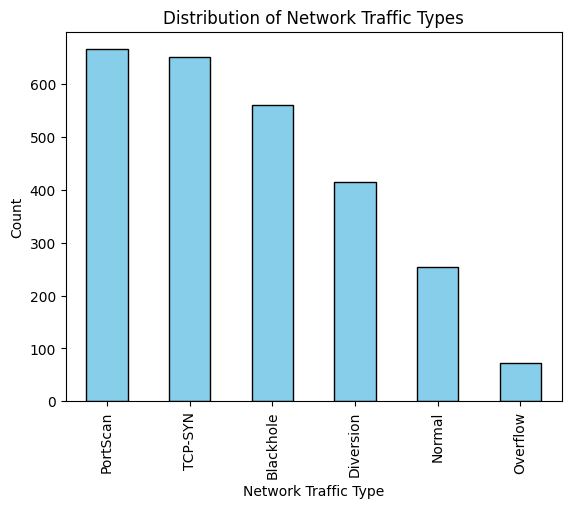

In [16]:
label_counts= df_train['Label'].value_counts()
print(label_counts)

label_counts.plot(kind='bar',color='skyblue', edgecolor='black')
plt.title("Distribution of Network Traffic Types")
plt.xlabel("Network Traffic Type")
plt.ylabel("Count")
plt.show()

## 4. Data Preprocessing

In [17]:
# ==========================================
# 4. DATA PREPROCESSING
# ==========================================

# 1. Save the answers (Labels) in a separate box just in case we need them later
train_labels = df_train['Label']

# 2. Define the text columns we need to remove so the model doesn't crash
cols_to_drop = ['Switch ID', 'Port Number', 'Label']

# 3. Create our clean, numbers-only training data by dropping those columns
X_train = df_train.drop(columns=cols_to_drop)

# 4. Check our new, clean data!
print("Cleaned Training Data Shape:", X_train.shape)
print("\n--- Data Types After Cleaning ---")
X_train.info()

Cleaned Training Data Shape: (2619, 19)

--- Data Types After Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2619 entries, 0 to 2618
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Received Packets               2619 non-null   int64
 1   Received Bytes                 2619 non-null   int64
 2   Sent Bytes                     2619 non-null   int64
 3   Sent Packets                   2619 non-null   int64
 4   Port alive Duration (S)        2619 non-null   int64
 5   Delta Received Packets         2619 non-null   int64
 6   Delta Received Bytes           2619 non-null   int64
 7   Delta Sent Bytes               2619 non-null   int64
 8   Delta Sent Packets             2619 non-null   int64
 9   Delta Port alive Duration (S)  2619 non-null   int64
 10  Connection Point               2619 non-null   int64
 11  Total Load/Rate                2619 non-null   int64
 12  T

## 5. Model Building: Isolation Forest

In [21]:
# ==========================================
# 5. MODEL BUILDING: ISOLATION FOREST
# ==========================================

# 1. Initialize (create) the Isolation Forest model
# We are guessing roughly 5% of the traffic might be anomalous
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Train the model on our clean, math-only data
print("Training the Isolation Forest model... (this might take a few seconds)")
iso_forest.fit(X_train)
print("Model Training Complete!")

# 3. Ask the model to score our data
# It will give a 1 for Normal, and a -1 for Anomaly
predictions = iso_forest.predict(X_train)

# 4. Create a new column in our table to hold these predictions
X_train['Anomaly_Prediction'] = predictions

# 5. Count how many normal connections vs anomalies the model found!
print("\nPrediction Results (1 = Normal, -1 = Anomaly):")
print(X_train['Anomaly_Prediction'].value_counts())

Training the Isolation Forest model... (this might take a few seconds)
Model Training Complete!

Prediction Results (1 = Normal, -1 = Anomaly):
Anomaly_Prediction
 1    2488
-1     131
Name: count, dtype: int64


## 6. Evaluation & Visualization

What were those 131 anomalies exactly?

Actual_Traffic
Normal       43
TCP-SYN      36
Blackhole    25
Diversion    13
PortScan     12
Overflow      2
Name: count, dtype: int64


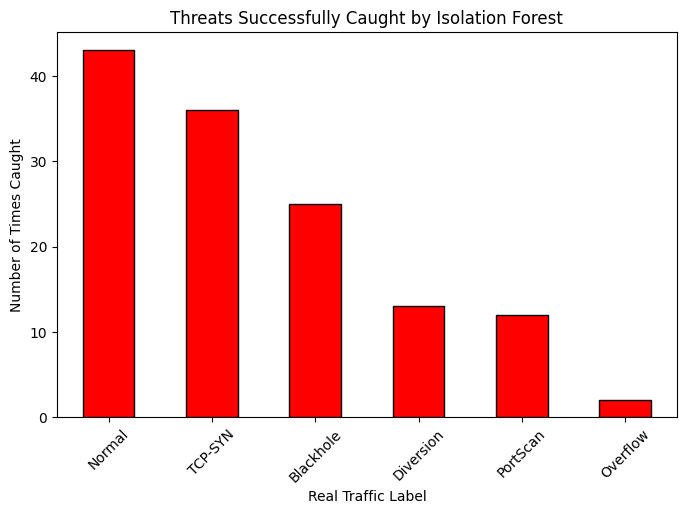

In [24]:
# ==========================================
# 6. EVALUATION & VISUALIZATION
# ==========================================

# 1. Create a brand new mini-table to compare answers side-by-side
results = pd.DataFrame({
    'Actual_Traffic': train_labels,
    'Prediction': X_train['Anomaly_Prediction']
})

# 2. Filter the table to ONLY look at the 131 anomalies the model caught
anomalies_only = results[results['Prediction'] == -1]

# 3. Count what types of attacks those 131 anomalies actually were
caught_attacks = anomalies_only['Actual_Traffic'].value_counts()
print("What were those 131 anomalies exactly?\n")
print(caught_attacks)

# 4. Draw a beautiful, professional graph for your GitHub portfolio
plt.figure(figsize=(8, 5))
caught_attacks.plot(kind='bar', color='red', edgecolor='black')
plt.title('Threats Successfully Caught by Isolation Forest')
plt.xlabel('Real Traffic Label')
plt.ylabel('Number of Times Caught')
plt.xticks(rotation=45)

# 5. Show the graph
plt.show()